# Aplicação de SVM

A base estudada será a de propensão a compra de carros.

**Configurações Iniciais**

In [1]:
from sklearn.svm import SVC
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report #, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('CARRO_CLIENTES.csv')
df.drop(columns=['User ID'], inplace=True)
df.head(3)

,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0


### Pré-processamento dos dados 
Como mostram os dados a seguir, a base não tem dados nulos, os tipos estão coerentes, não há valores inaprópriados ou com erros de digitação.

A ausência de outliers foi dicutida em projetos anteriores como, por exemplo, o projeto XGBoost.

In [3]:
print(f'Tamanho: {df.shape}\n\nNulos:\n{df.isnull().sum()}\n\n')
print(df.info())

Tamanho: (1000, 4)

Nulos:
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Gender        1000 non-null   object
 1   Age           1000 non-null   int64 
 2   AnnualSalary  1000 non-null   int64 
 3   Purchased     1000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 31.4+ KB
None


In [4]:
print('Valores Únicos por coluna categorica ou binária:\n')
print(df['Gender'].unique())
print(df["Purchased"].unique())

Valores Únicos por coluna categorica ou binária:

['Male' 'Female']
[0 1]


#### Tratamento das variáveis categóricas

In [5]:
label_encoder = LabelEncoder()
categorias = ['Gender']
for categoria in categorias:
    df[categoria] = label_encoder.fit_transform(df[categoria])
print(df.head())

   Gender  Age  AnnualSalary  Purchased
0       1   35         20000          0
1       1   40         43500          0
2       1   49         74000          0
3       1   40        107500          1
4       1   25         79000          0


### Matriz de Correlação

A matriz de correalação da base mostra a correlação entre as variáveis. Abaixo é possível ver a matriz completa. Para fins de análise, a matriz foi dividida em duas: a primeira com as corelações 'fortes', com módulo acima de 0.5, e fracas, as restantes. Os valores igual a 1 foram excluídos pois representam informação redundante.

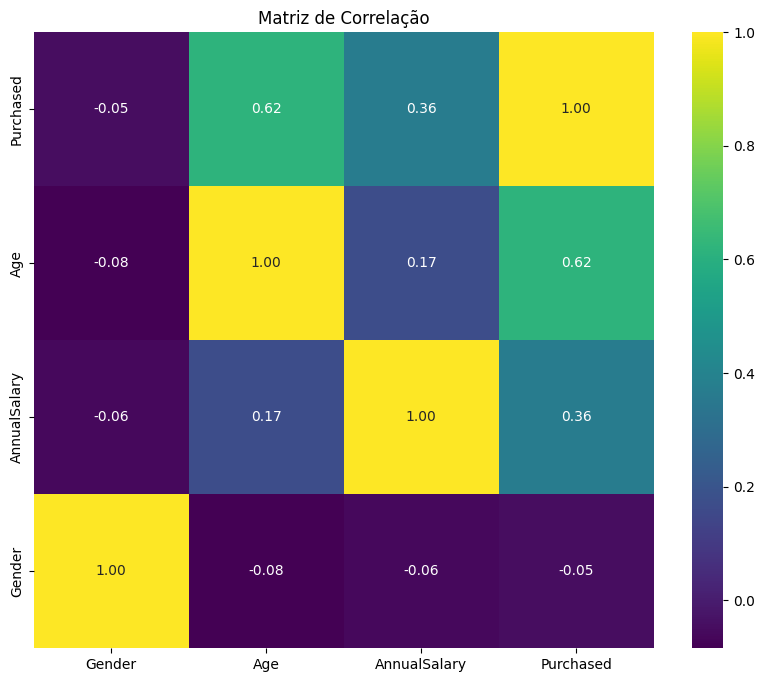

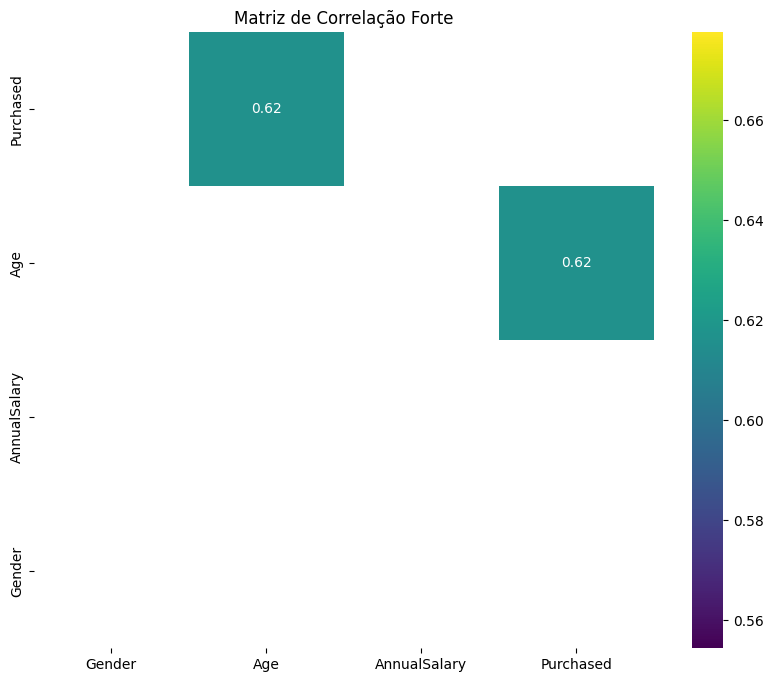

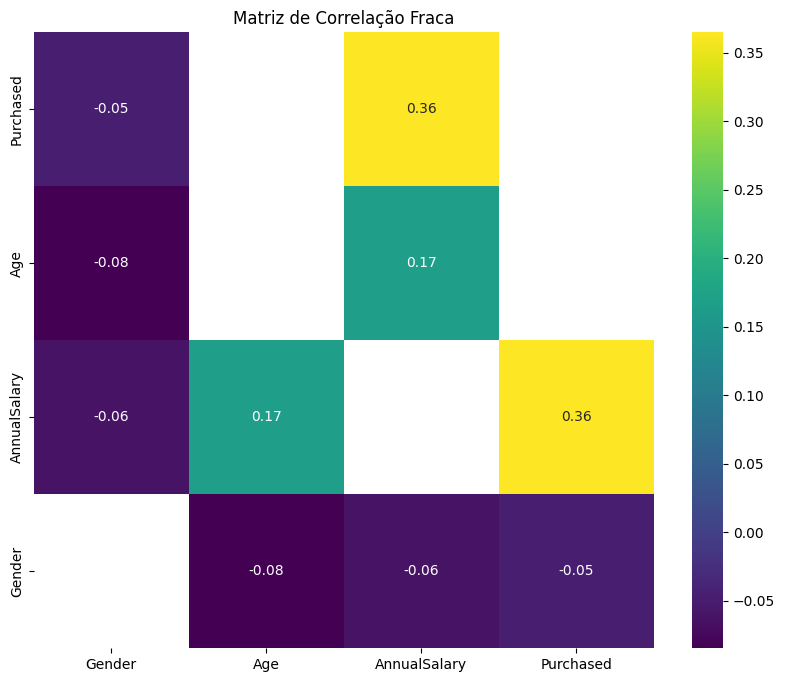

In [6]:
alvo = 'Purchased'
correlation_matrix = df.select_dtypes(include=['number']).corr()
correlation_matrix.sort_values(by=alvo, ascending=False, inplace=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

# Correlações Fortes
plt.figure(figsize=(10, 8))
correlation_matrix_strong = correlation_matrix[(correlation_matrix.abs() >= 0.5) & (correlation_matrix != 1)]
sns.heatmap(correlation_matrix_strong, annot=True, cmap='viridis', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação Forte')
plt.show()

# Correlações "Fracas"
plt.figure(figsize=(10, 8))
correlation_matrix_strong = correlation_matrix[correlation_matrix.abs() < 0.5]
sns.heatmap(correlation_matrix_strong, annot=True, cmap='viridis', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação Fraca')
plt.show()

A correlação mais forte, e única superior a 0,5, é a relação entre compra (Purchased) e idade (Age). A relação não é muito forte, o que indica que, apesar da forte influência, as outras variáveis podem também influenciar, mesmo que pouco.

Dentre as relações mais fracas, todas as relações com gênero são fracas. Isso indica que essa variável não influencia na probabilidade de compra. Chama atenção a relação entre salário anual (AnnualSalary) e idade: já que a última foi identificada como uma forte influência para compra, sua relação com salário anual é carregada para a probabilidade de compra. Essa influencia pode ser vista na relação entre salário anual e compra, que, ainda que pequena, é a segunda maior.

A forte relação com idade pode indicar que a chance de compra está relacionada a necessidades ou mudanças de comportamento comuns de determinadas idades, mas a relação com salário anual acrescenta que a compra vai depender das ocndições financeiras do cliente.

### Separação da base em X e Y e de treino e teste.

In [23]:
X = df.drop('Purchased', axis = 1)
Y = df['Purchased']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=42)

Como o SVM é sensível à escala dos dados, não os escalar pode resultar em um modelo ineficiente.

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

### Treino do modelo **SVM** com o **kernel linear**.

In [25]:
svm_model = SVC(kernel =  'linear', random_state = 1, C = 1.0)
svm_model.fit(X_train_scaled,Y_train)

# outras opções de kernel: poly, rbf

SVC(kernel='linear', random_state=1)

#### Previsões do Modelo

In [26]:
Y_pred = svm_model.predict(X_test_scaled)

#### Avaliação do Modelo

Conforme as métricas abaixo, o desempenho do SVM com kernel linear foi inferior ao do XGBoost. Os valores de falsos positivos e falsos negativos não são grandes, resultado esse compatível com os valores de precisão, sensibilidade, acurácia e f1.

Destaca-se um desempenho pior na predição de vendas (1) do que de não-vendas (0).

In [27]:
accuracy = accuracy_score(Y_test, Y_pred)
print("Acurácia:", accuracy)
report = classification_report(Y_test, Y_pred)
print("Relatório de Classificação:\n", report)


Acurácia: 0.825
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.79      0.94      0.86       231
           1       0.90      0.66      0.76       169

    accuracy                           0.82       400
   macro avg       0.84      0.80      0.81       400
weighted avg       0.84      0.82      0.82       400



Matriz de Confusão:


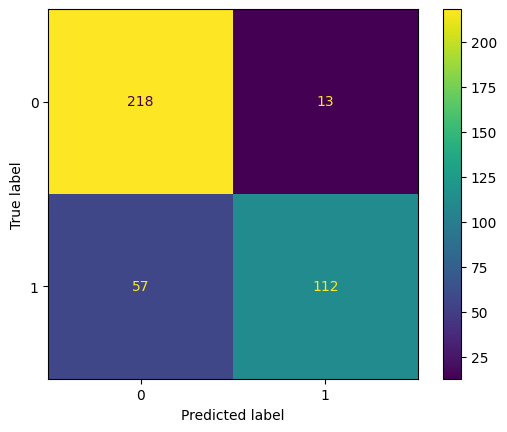

In [28]:
print('Matriz de Confusão:')
print(ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred))

# 7. Treine um novo modelo SVM com sua base de treino + realize as previsões e avalições.
Esse modelo dedve ser treinado usando o kernel poly.

### Treino do modelo **SVM** com o **kernel rbf**.

In [33]:
svm_model = SVC(kernel =  'rbf', random_state = 1, C = 1.0)
svm_model.fit(X_train_scaled,Y_train)


SVC(random_state=1)

#### Previsões do Modelo

In [34]:
Y_pred_rbf = svm_model.predict(X_test_scaled)

#### Avaliaçã do Modelo

In [35]:
accuracy_rbf = accuracy_score(Y_test, Y_pred_rbf)
print("Acurácia:", accuracy_rbf)
report_rbf = classification_report(Y_test, Y_pred_rbf)
print("Relatório de Classificação:\n", report_rbf)

Acurácia: 0.905
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       231
           1       0.89      0.88      0.89       169

    accuracy                           0.91       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.91      0.90       400



Matriz de Confusão:


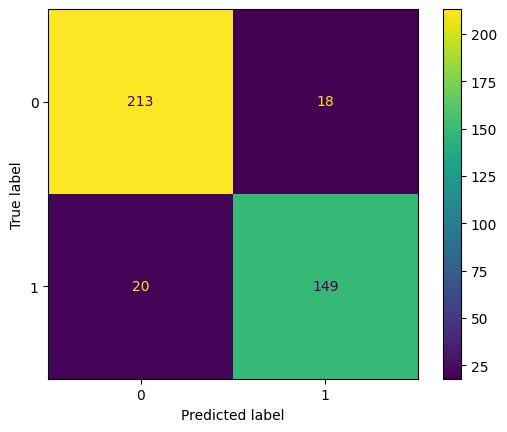

In [36]:
print('Matriz de Confusão:')
print(ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred_rbf))

## Comparação entre Modelos

Os resultados para o kernel rbf, em comparação com os do kernel linear, foram melhores em todos os índices. 

Apesar das predições de falsos positivos terem tido um desempenho equivalente em ambos os modelos, o melhor desempenho nas previsões de falsos negativos influenciou no melhor desempenho geral do rbf em relação ao linerar.

Lembrando que, neste caso, falsos positivos são previsões falsas de vendas,ou seja, vendas previstas que não ocorreram. Já os falsos negativos são previsões de não-vendas que resultaram, na verdade, em vendas.

Cada tipo de análise vai dar maior ou menor importância para essa diferença. No nosso caso, o grande problema está nas previsões de faturamento que. Prever erroneamente que algumas vendas não irão ocorrer não é tão grave quanto prever que que mais vendas irão ocorrer. Isso por que esses falsos positivos geram uma perspectiva de crescimento inflada.

O modelo XGBoost apresentou um desempenho superior ao SVM com kernel linear, mas muito similar ao SVM com kernel rbf. Os modelos tiveram diferentes desempenhos para difrentes variáveis, de maneira que a escolha do modelo mais adequado, e dos melhores parâmetros, depende de cada caso e deve ser estudado e testado antes de serem escolhidos como definitivos para a pesquisa.